# Język Python w Analizie Danych
#

## Cel zajęć
- Wczytywanie danych z plików CSV i JSON
- Identyfikacja oraz obsługa brakujących danych
- Uzupełnianie braków różnymi metodami
- Przygotowanie danych do użycia w Pandas i NumPy


### Dokumentacja:
- Pandas: https://pandas.pydata.org/docs/
- NumPy: https://numpy.org/doc/stable/


### Przykłady

In [ ]:
# Wczytywanie danych z pliku CSV
import pandas as pd
df_csv = pd.read_csv('data/example_data_missing.csv')
df_csv

,id,value,category
0,a1,10.5,x
1,b2,NaN,y
2,c3,7.8,NaN
3,d4,12.1,z
4,NaN,NaN,x


In [14]:
# Wczytywanie danych z pliku JSON
df_json = pd.read_json('data/example_data_missing.json')
df_json

,name,age,score
0,Alice,25.0,NaN
1,None,30.0,88.5
2,Charlie,NaN,NaN
3,Diana,22.0,91.0


In [18]:
# Usuwanie wybranej kolumny jeśli występują w niej braki
if df_json["age"].isna().any():
        df_drop_column =  df_json.drop(columns=["age"])
print(df_drop_column)

      name  score
0    Alice    NaN
1     None   88.5
2  Charlie    NaN
3    Diana   91.0


In [4]:
#Usuwanie rekordów z brakami
df_drop = df_csv.dropna()
df_drop

,id,value,category
0,a1,10.5,x
3,d4,12.1,z


In [5]:
# Uzupełnianie braków średnią
df_mean = df_csv.fillna(df_csv.mean(numeric_only=True))
df_mean

,id,value,category
0,a1,10.500000,x
1,b2,10.133333,y
2,c3,7.800000,NaN
3,d4,12.100000,z
4,NaN,10.133333,x


In [11]:
# Usuwanie rekordów z brakami w wybranej kolumnie
df_drop = df_mean.dropna(subset=["category"])
print(df_drop)

    id      value category
0   a1  10.500000        x
1   b2  10.133333        y
3   d4  12.100000        z
4  NaN  10.133333        x


In [6]:
# Uzupełnianie braków medianą
df_median = df_json.fillna(df_json.median(numeric_only=True))
df_median

,name,age,score
0,Alice,25.0,89.75
1,None,30.0,88.50
2,Charlie,25.0,89.75
3,Diana,22.0,91.00


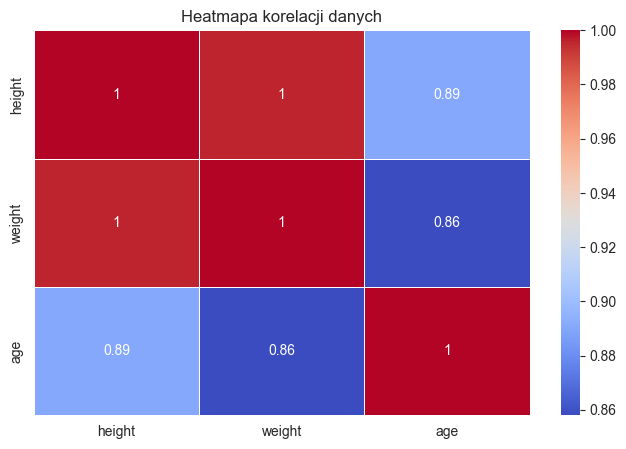

In [3]:
# Przykład heatmapy korelacji danych
import seaborn as sns
import matplotlib.pyplot as plt

# Przykładowy DataFrame
data = {
    "id": ['a1', 'b2', 'c3', 'd4', 'e5'],
    "name": ['Tom', 'Sarah', 'Cristopher', 'Frank', 'Penny'],
    "height": [170, 165, 180, 175, 160],
    "weight": [70, 60, 85, 78, 55],
    "age": [22, 25, 30, 28, 19]
}

df = pd.DataFrame(data)

df_num = df.select_dtypes(include=["int", "float"])

# Obliczenie macierzy korelacji
corr = df_num.corr()

# Stworzenie heatmapy
plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Heatmapa korelacji danych")
plt.show()

In [7]:
#Uzupełnianie braków losowymi wartościami
import numpy as np
df_rand = df_csv.copy()
for col in df_rand.select_dtypes(include=['float','int']).columns:
    mask = df_rand[col].isna()
    df_rand.loc[mask, col] = np.random.uniform(df_rand[col].min(), df_rand[col].max(), mask.sum())
df_rand

,id,value,category
0,a1,10.500000,x
1,b2,8.826102,y
2,c3,7.800000,NaN
3,d4,12.100000,z
4,NaN,11.664317,x


## Wielokrotna imputacja

In [6]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd

df = pd.read_csv("data/example_importance_data.csv")
df.drop(columns=["id", "category"], inplace=True)
print(df)

     strong_1    strong_2     medium     low_1     low_2     low_3       value
0   98.479231   61.885751  45.413294  6.420316  2.944489  0.516817   88.558760
1   88.756641   98.184625        NaN  0.841400  3.850977  5.313546   85.715563
2   96.974947   78.861359   7.244744  1.616287  8.511367  5.406351   79.613622
3   94.741368   90.514241  24.472638  8.985542  3.169220  6.374299   90.343721
4   79.894999  114.453988  49.282523  6.064291  1.694927  7.260913   94.665673
5   96.093712   74.957534  12.102764  0.091971  5.568013  9.758521   79.861685
6   54.424625   84.622975  33.606777  1.014715  9.361548  5.163003   66.647887
7   59.799143         NaN  38.080981  6.635018  6.960298  3.229565   76.450957
8   52.261364   73.727890  11.881877  0.050616  5.700612  7.951862   57.402976
9   66.266517   64.618795  36.410817  1.608081  0.971765  2.708323   68.400680
10  69.433864   77.385087  18.389157  5.487338  6.150072  4.389714   73.924432
11  63.567452   69.673277  31.615292  6.918952  9.90

In [7]:
imputer = IterativeImputer(random_state=42, max_iter=10)

df_imputed_array = imputer.fit_transform(df)

df_imputed = pd.DataFrame(df_imputed_array, columns=df.columns)
print(df_imputed)

     strong_1    strong_2     medium     low_1     low_2     low_3       value
0   98.479231   61.885751  45.413294  6.420316  2.944489  0.516817   88.558760
1   88.756641   98.184625  13.388406  0.841400  3.850977  5.313546   85.715563
2   96.974947   78.861359   7.244744  1.616287  8.511367  5.406351   79.613622
3   94.741368   90.514241  24.472638  8.985542  3.169220  6.374299   90.343721
4   79.894999  114.453988  49.282523  6.064291  1.694927  7.260913   94.665673
5   96.093712   74.957534  12.102764  0.091971  5.568013  9.758521   79.861685
6   54.424625   84.622975  33.606777  1.014715  9.361548  5.163003   66.647887
7   59.799143   98.150727  38.080981  6.635018  6.960298  3.229565   76.450957
8   52.261364   73.727890  11.881877  0.050616  5.700612  7.951862   57.402976
9   66.266517   64.618795  36.410817  1.608081  0.971765  2.708323   68.400680
10  69.433864   77.385087  18.389157  5.487338  6.150072  4.389714   73.924432
11  63.567452   69.673277  31.615292  6.918952  9.90

### Zadanie 1
Wczytaj dane `data_fill.json`. Sprawdź podstawowe informacje o danych. Wyświetl liczbę braków danych w każdej kolumnie.

In [47]:
# TODO: Task 1

### Zadanie 2
Stwórz kopię danych z zadania 1. Usuń wszystkie wiersze, które mają braki w kluczowych kolumnach `Age`, `Gender`, `Diabetes`. Oceń przy pomocy funkcji `shape()` wpływ usunięcia danych na rozmiar zbioru.

In [ ]:
# TODO: Task 2

### Zadanie 3
Stwórz kopię danych z zadania 1.

a) Wypełnij braki w kolumnie Age medianą.

b) Wypełnij braki w kolumnie Scholarship wartością 0.

c) Wypełnij braki w kolumnie Handcap metodą „forward fill”.

d) Wypełnij braki w AppointmentDay i ScheduledDay metodą „most frequent”.

e) Wyświetl DataFrame po imputacji.

In [ ]:
# TODO: a)

In [ ]:
# TODO: b)

In [ ]:
# TODO: c)

In [ ]:
# TODO: d)

In [ ]:
# TODO: e)

### Zadanie 4
Usuń kolumny nienumeryczne, których nie da się zakodować (np. ID). Dla kolumny `Gender` zmień wartość `M` na 0 i `F` na 1.

In [ ]:
# TODO: Task 4

### Zadanie 5
Wczytaj kopię danych z pliku `data_fill.json`. Przygotuj dane podobnie jak w poprzednich zadaniach (usuń dane, zamień wartości), ale nie wypełniaj danych. Wykorzystując bibliotekę `scikit-learn` zastosuj wielokrotną imputację do wypełnienia brakujących danych numerycznych. Porównaj DataFramy z wypełnionymi danymi.

In [ ]:
# TODO: Task 5